# Lesson 6: Exploratory Data Analysis (EDA)

## Missing Values, Outliers, Visualization, and Exploration

In this notebook we will:
- Perform systematic EDA on a real dataset
- Detect and handle missing values
- Identify outliers using IQR and Z-score methods
- Create effective visualizations

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

## 1. Data Overview

In [2]:
titanic = sns.load_dataset('titanic')
print("Shape:", titanic.shape)
print("\nInfo:")
titanic.info()
print("\nHead:")
titanic.head()

Shape: (891, 15)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

Head:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Missing Value Analysis

             Missing  Percentage
age              177   19.865320
embarked           2    0.224467
deck             688   77.216611
embark_town        2    0.224467


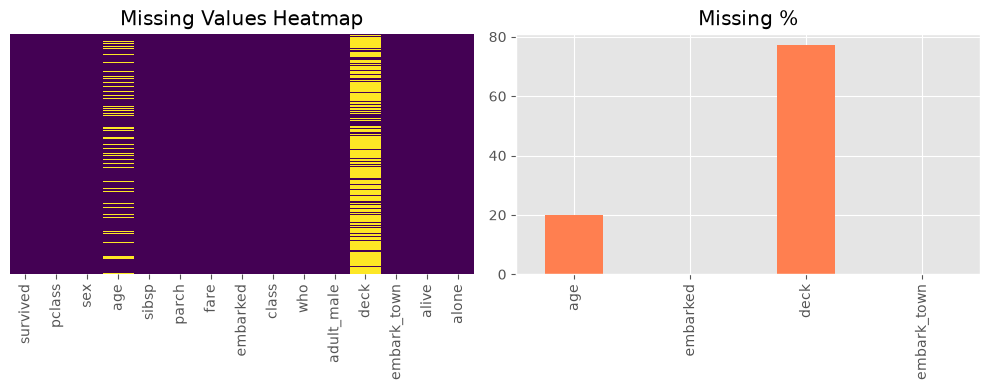

In [3]:
missing = titanic.isnull().sum()
missing_pct = (missing / len(titanic)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(titanic.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.subplot(1, 2, 2)
missing_pct[missing_pct > 0].plot(kind='bar', color='coral')
plt.title('Missing %')
plt.tight_layout()
plt.show()

## 3. Univariate Analysis

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


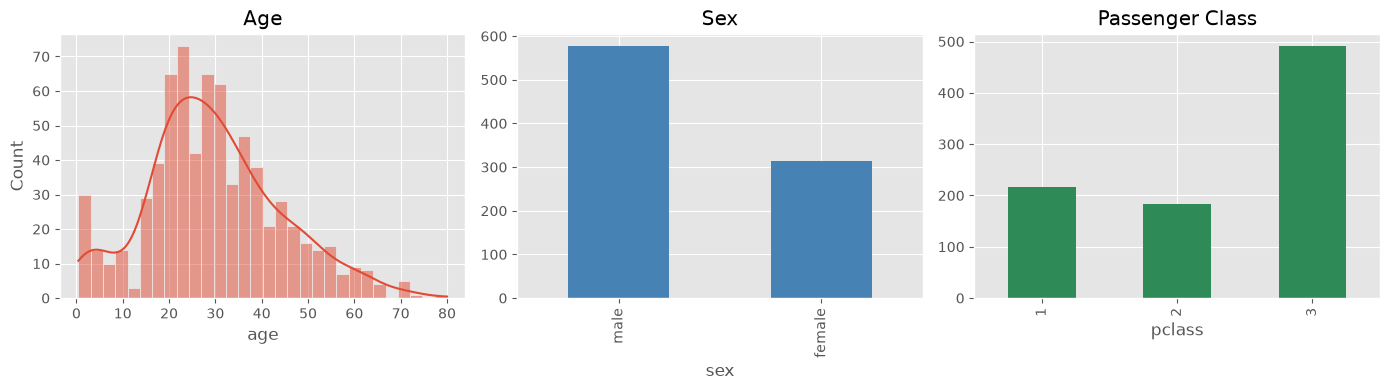

In [4]:
print(titanic.describe())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(titanic['age'].dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age')
titanic['sex'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Sex')
titanic['pclass'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Passenger Class')
plt.tight_layout()
plt.show()

## 4. Bivariate Analysis

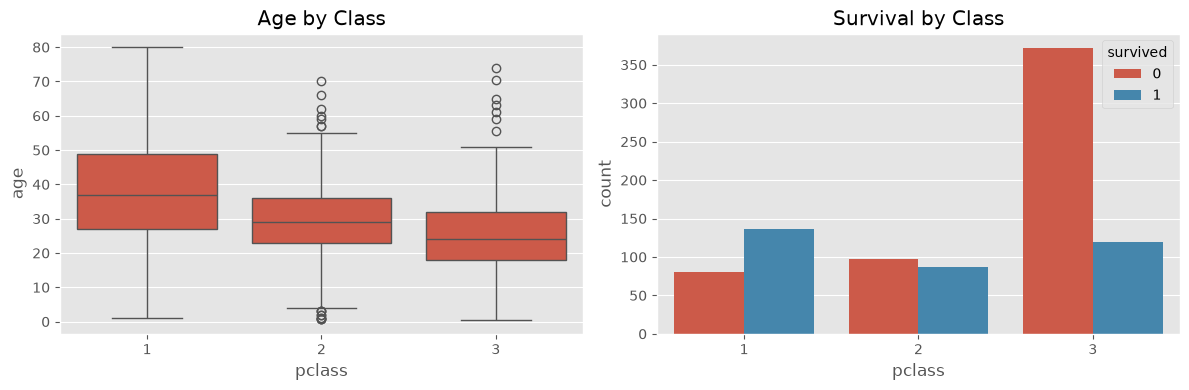

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='pclass', y='age', data=titanic, ax=axes[0])
axes[0].set_title('Age by Class')
sns.countplot(x='pclass', hue='survived', data=titanic, ax=axes[1])
axes[1].set_title('Survival by Class')
plt.tight_layout()
plt.show()

## 5. Outlier Detection

Fare outliers: 116 rows
IQR bounds: [$-26.72, $65.63]


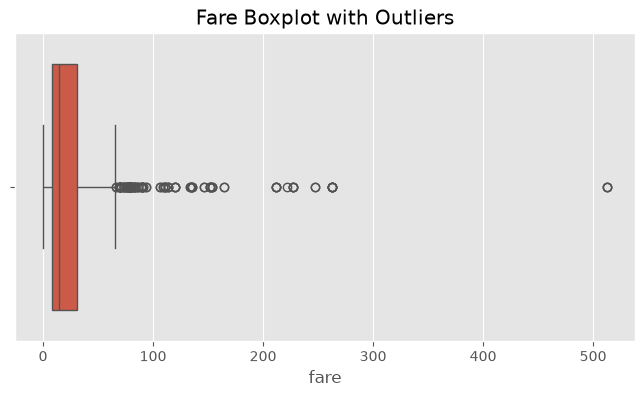

In [6]:
q1 = titanic['fare'].quantile(0.25)
q3 = titanic['fare'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = titanic[(titanic['fare'] < lower) | (titanic['fare'] > upper)]
print(f"Fare outliers: {len(outliers)} rows")
print(f"IQR bounds: [${lower:.2f}, ${upper:.2f}]")

plt.figure(figsize=(8, 4))
sns.boxplot(x=titanic['fare'])
plt.title('Fare Boxplot with Outliers')
plt.show()

## 6. Handling Missing Values

In [7]:
titanic_clean = titanic.copy()
titanic_clean['age'].fillna(titanic_clean['age'].median(), inplace=True)
titanic_clean['embarked'].fillna(titanic_clean['embarked'].mode()[0], inplace=True)
titanic_clean.drop(columns=['deck'], inplace=True)
print(f"Missing after cleaning: {titanic_clean.isnull().sum().sum()}")

Missing after cleaning: 181


/tmp/ipykernel_34661/1062265134.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic_clean['age'].fillna(titanic_clean['age'].median(), inplace=True)
/tmp/ipykernel_34661/1062265134.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inp

## Exercises

1. Load `tips` from seaborn and perform a complete EDA.
2. Write an `outlier_report(df, column)` function.
3. Generate a pandas-profiling report for the titanic dataset.